In [17]:
%load_ext autoreload
%autoreload 2

'''
Importing the modules
'''
import config_2D_coupling_V2 as cfg         # config = physical & simulation parameters 
from solver_2D_coupling_V2 import *         # solver = FEM method + pmls
import numpy as np 
import copy
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from ngsolve import exp, IfPos
from scipy.interpolate import PchipInterpolator

def create_density_profile(x_sym, z_sym):
    '''
    Define a 2D (x,z) arbitrary profile of density n_e(x,z).
    Upgraded with PCHIP spline for C1 continuity to prevent FEM reflections.
    '''
    # TYPE: str
    prof_type = cfg.PLASMA.get('profile_type', 'exponential')

    if prof_type == 'exponential':
        # TYPE: float
        Lx_plasma = cfg.DOMAIN['Lx_plasma']
        n_edge = cfg.PLASMA['n_edge']
        n_core = cfg.PLASMA['n_core']

        # TYPE: float
        lambda_val = np.log(n_core / n_edge) / Lx_plasma
        
        # TYPE: ngsolve.CoefficientFunction
        n_e_profile = n_edge * exp(lambda_val * x_sym)
        return n_e_profile

    elif prof_type == 'piecewise_linear':
        # Convert points to numpy arrays
        # TYPE: np.ndarray, SHAPE: (N,)
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])

        # Compute Hermite Spline coefficients to ensure smooth monotonic transitions
        # TYPE: scipy.interpolate.PchipInterpolator
        spline = PchipInterpolator(x_pts, n_pts)

        # TYPE: float | ngsolve.CoefficientFunction
        n_e_profile = 0.0

        for i in range(len(x_pts) - 1):
            # TYPE: float
            x0, x1 = x_pts[i], x_pts[i+1]

            # Extract cubic polynomial coefficients for segment i
            # TYPE: float
            c3, c2, c1, c0 = spline.c[:, i]

            # TYPE: ngsolve.CoefficientFunction
            dx = x_sym - x0
            poly = c3*dx**3 + c2*dx**2 + c1*dx + c0

            # Masking to apply polynomial only on the local segment
            # TYPE: ngsolve.CoefficientFunction
            if i == len(x_pts) - 2:
                mask = IfPos(x_sym - x0, 1.0, 0.0)
            else:
                mask = IfPos(x_sym - x0, 1.0, 0.0) - IfPos(x_sym - x1, 1.0, 0.0)

            n_e_profile = n_e_profile + mask * poly

        return n_e_profile
    else:
        raise ValueError("Profile type not supported. Use 'exponential' or 'piecewise_linear'.")

In [19]:
def converg_study(mult_ratio):
# Create lists to store iteration results
    dofs_list = []
    power_list = []
    cpu_time_list = []

    for r in mult_ratio:
    # Create a complete copy of the dict cfg to modify it without affect the original one      
        cfg_copy = {}
        for key, val in cfg.__dict__.items(): # scan cfg file  
            if not key.startswith('__') and isinstance(val, dict): # avoid python system hidden files starting with '__' that are not iterable ==> otherwise the code crash 
                cfg_copy[key] = copy.deepcopy(val)                 # Recover only the dicts and the variables
        print('cfg_copy: ', cfg_copy)
        cfg_copy['DOMAIN']['nx_plasma'] = int(cfg_copy['DOMAIN']['nx_plasma'] * r)
        cfg_copy['DOMAIN']['nz_plasma'] = int(cfg_copy['DOMAIN']['nz_plasma'] * r)
        cfg_copy['DOMAIN']['nx_pml'] = int(cfg_copy['DOMAIN']['nx_pml'] * r)
        cfg_copy['DOMAIN']['nz_pml'] = int(cfg_copy['DOMAIN']['nz_pml'] * r)
        print('New Mesh: nx = ', {cfg_copy['DOMAIN']['nx_plasma']}, 'nz = ', {cfg_copy['DOMAIN']['nz_plasma']}, 'nx_pml = ',{cfg_copy['DOMAIN']['nx_pml']}, 'nz_pml = ', {cfg_copy['DOMAIN']['nz_pml']})
    
    # Create a new solver based on the new cfg dict previously generated
        solver = LHCouplingSolver(cfg_copy)  
        t0 = time.time()        # Timer Start
    # Solve the pb using the cgf dict and FEM solver method
        solver.build_mesh()
        solver.build_physics(lambda x_sym, z_sym: create_density_profile(x_sym, z_sym))
        solver.solve_system()          

        t1 = time.time()        # Timer Stop
        cpu_time = t1-t0        # Compute CPU time for this iteration

        dofs = solver.fes.ndof  # Recover the dofs

    # To compute the integration of power density over the plasma region
        Lx_plasma = cfg_copy['DOMAIN']['Lx_plasma']
        Lz_tot = cfg_copy['DOMAIN']['Lz_tot']
        Lz_pml = cfg_copy['DOMAIN']['Lz_pml']
    # To not take into account the pml region
        mask_x = IfPos(Lx_plasma - solver.x_sym, 1.0, 0.0)
        mask_z_bot = IfPos(solver.z_sym - Lz_pml, 1.0, 0.0)
        mask_z_top = IfPos((Lz_tot - Lz_pml) - solver.z_sym, 1.0, 0.0)
        mask_tot = mask_x * mask_z_bot * mask_z_top 
    # Compute the power density on the plasma region domain 
        from ngsolve import Conj
            
            # 1. Extraction des composantes scalaires
        Ex = solver.E_field.components[0]
        Ey = solver.E_field.components[1]
        Ez = solver.E_field.components[2]
        norm_E_squared = Ex * Conj(Ex) + Ey * Conj(Ey) + Ez * Conj(Ez)
        
        power_density = mask_tot * norm_E_squared
        total_power = Integrate(power_density, solver.mesh).real
        
    # Store the results:
        print('--- Storing results ---')
        dofs_list.append(dofs)
        power_list.append(total_power)
        cpu_time_list.append(cpu_time)
    
    print(f'dofs: {dofs}, total_power: {total_power}, cpu_time_list: {cpu_time}')

    return np.array(dofs_list), np.array(power_list), np.array(cpu_time_list) 


In [22]:
# Study 
ratio = np.linspace(0.25, 2, 15)
dofs_array, power_array, cpu_time_array = converg_study(ratio)

cfg_copy:  {'CONST': {'c0': 299792458, 'q_e': 1.602176634e-19, 'm_e': 9.10938356e-31, 'm_i': 3.344325545999999e-27, 'eps_0': 8.854187817e-12}, 'GEOM': {'R0': 2.5, 'R_ant': 3.0}, 'WAVE': {'f': 3700000000.0, 'n_para': 2.0, 'E_inc': 10.0, 'omega_wave': 23247785636.56447, 'k0': 77.54626581221223}, 'DOMAIN': {'Lx_plasma': 0.1, 'Lx_pml': 0.1, 'Lz_plasma': 0.4, 'Lz_pml': 0.05, 'nx_plasma': 100, 'nx_pml': 50, 'nz_plasma': 100, 'nz_pml': 50, 'order': 2, 'sigma_max_factor': 10000.0, 'degree': 2.0, 'Lx_tot': 0.2, 'Lz_tot': 0.5}, 'PLASMA': {'B0_center_plasma': 3.7, 'theta_B_deg': -5.0, 'phi_B_deg': 0.0, 'n_edge': 1e+16, 'n_core': 5e+19, 'L_grad': 0.05, 'theta_B_rad': -0.08726646259971647, 'phi_B_rad': 0.0, 'n_crit': 1.698165902198677e+17, 'x_crit': 0.14160669402927525, 'profile_type': 'exponential', 'lin_prof_x': [0.0, 0.08333333333333333, 0.1], 'lin_prof_n': [1e+18, 7e+18, 1e+19]}}
New Mesh: nx =  {25} nz =  {25} nx_pml =  {12} nz_pml =  {12}
Degrees of freedom: 7803
--- Système solved ---
--- St

dofs_array:  [  7803  16875  30603  46875  68403  91875 121203 151875 189003 226875
 271803 316875 369603 421875 482403]
power_array:  [ 6.14579318  5.7112882   7.37601336  5.43689258 12.41884672  7.52690586
  6.61997646  5.96938361  5.69434017 14.65995101  7.03757514  5.89156307
  5.50061284 16.04520872  6.41221157]
cpu_time_array:  [ 0.30478692  0.65792847  1.35234761  1.8614614   2.26288247  3.13288999
  5.81496739  7.45040011  9.43583798 11.48230577 15.23015141 16.56123042
 19.49559617 22.82726216 27.8208735 ]

--- Génération des graphiques de convergence ---


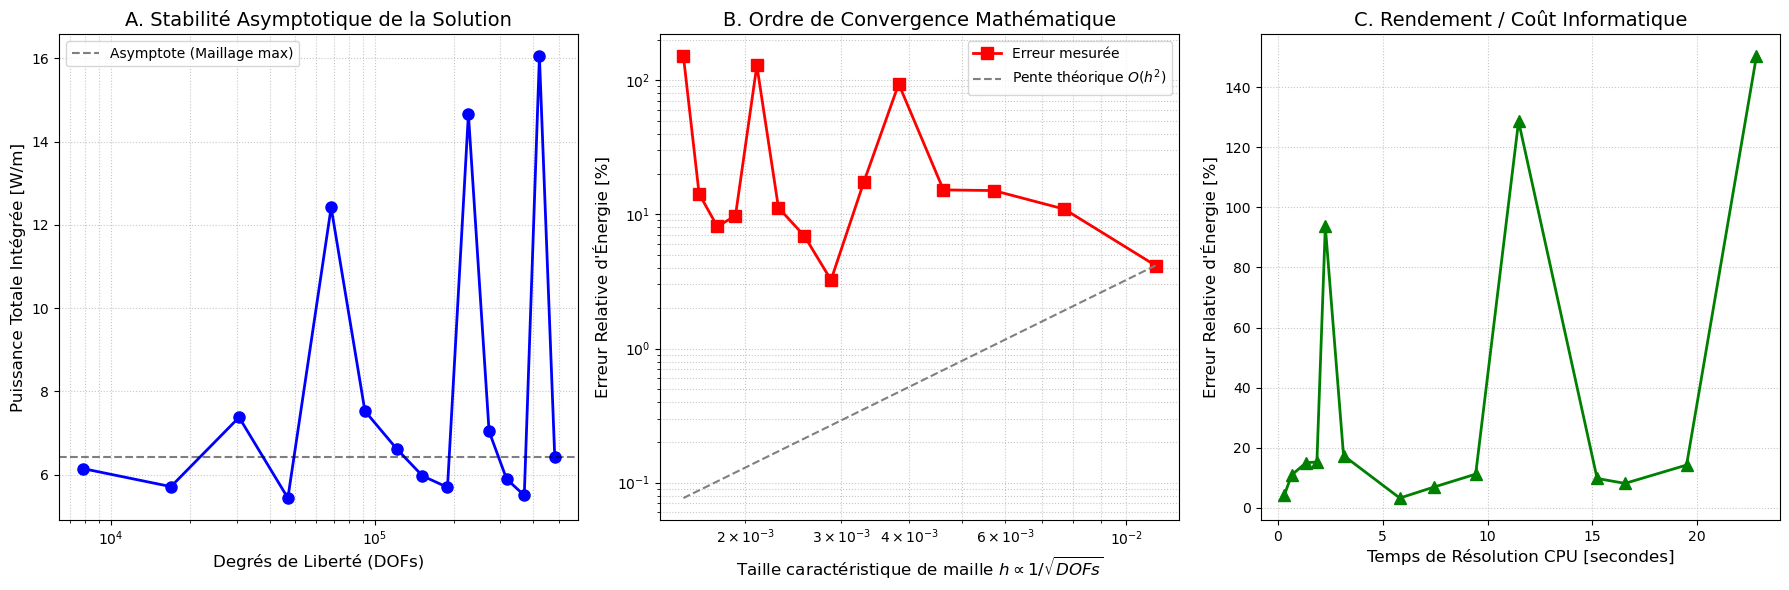

In [23]:
import matplotlib.pyplot as plt

def plot_convergence_results(dofs, powers, times):
    """
    Génère le triptyque de graphiques de convergence au standard académique.
    dofs, powers, times doivent être des np.array issus de la boucle d'étude.
    """
    print("\n--- Génération des graphiques de convergence ---")
    
    # 1. Traitement mathématique des données
    # On considère la dernière valeur (la plus fine) comme la solution "exacte" de référence
    P_exact = powers[-1]
    
    # Calcul de l'erreur relative en % (on exclut le dernier point car l'erreur vaut 0)
    relative_errors = np.abs((powers[:-1] - P_exact) / P_exact) * 100
    
    # En 2D, la taille d'une maille h est proportionnelle à 1/sqrt(DOFs)
    h_mesh = 1.0 / np.sqrt(dofs[:-1])
    
    # 2. Création de la figure (Triptyque horizontal)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    # --- Graphe A : Valeur Asymptotique (DOFs vs Puissance) ---
    axs[0].plot(dofs, powers, marker='o', color='blue', linewidth=2, markersize=8)
    axs[0].axhline(y=P_exact, color='black', linestyle='--', alpha=0.5, label='Asymptote (Maillage max)')
    axs[0].set_xscale('log') # Echelle log pour bien espacer les DOFs
    axs[0].set_xlabel('Degrés de Liberté (DOFs)', fontsize=12)
    axs[0].set_ylabel('Puissance Totale Intégrée [W/m]', fontsize=12)
    axs[0].set_title('A. Stabilité Asymptotique de la Solution', fontsize=14)
    axs[0].grid(True, which="both", linestyle=':', alpha=0.7)
    axs[0].legend()
    
    # --- Graphe B : Ordre de Convergence (h vs Erreur) LOG-LOG ---
    # On ajoute une droite de référence théorique O(h^2) ou O(h^3)
    ref_slope_h2 = (h_mesh / h_mesh[0])**2 * relative_errors[0]
    
    axs[1].loglog(h_mesh, relative_errors, marker='s', color='red', linewidth=2, markersize=8, label='Erreur mesurée')
    axs[1].loglog(h_mesh, ref_slope_h2, linestyle='--', color='gray', label='Pente théorique $O(h^2)$')
    axs[1].set_xlabel(r'Taille caractéristique de maille $h \propto 1/\sqrt{DOFs}$', fontsize=12)
    axs[1].set_ylabel('Erreur Relative d\'Énergie [%]', fontsize=12)
    axs[1].set_title('B. Ordre de Convergence Mathématique', fontsize=14)
    axs[1].grid(True, which="both", linestyle=':', alpha=0.7)
    axs[1].legend()
    
    # --- Graphe C : Le Front de Pareto (Temps vs Erreur) ---
    # On associe le temps de l'itération à l'erreur qu'elle produit
    axs[2].plot(times[:-1], relative_errors, marker='^', color='green', linewidth=2, markersize=8)
    axs[2].set_xlabel('Temps de Résolution CPU [secondes]', fontsize=12)
    axs[2].set_ylabel('Erreur Relative d\'Énergie [%]', fontsize=12)
    axs[2].set_title('C. Rendement / Coût Informatique', fontsize=14)
    axs[2].grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("Convergence_Study_Results.pdf", dpi=300)
    plt.show()

print('dofs_array: ', dofs_array)
print('power_array: ', power_array)
print('cpu_time_array: ', cpu_time_array)
plot_convergence_results(dofs_array, power_array, cpu_time_array)